In [4]:
import numpy as np
import pandas as pd
import mlflow
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from scipy import stats
import os

BASE_DIR = os.path.abspath("..")
mlflow.set_tracking_uri(f"sqlite:///{BASE_DIR}/mlflow.db")
N_BINS = 10
EXPERIMENT_NAME = "BP:NACC - finalne hodnotenie + kalibracia"

# Kalibračná analýza vytvorených prediktívnych modelov


In [9]:
def load_predictions(experiment_name):
    client = mlflow.tracking.MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="attributes.status = 'FINISHED'"  )
        
    TARGET_RUNS = {"LogReg_FINAL_MODEL", "XGBoost_FINAL_MODEL", "SVM_FINAL_MODEL"}    
    model_probability = {}
    y_true = None
    for run in runs:
        run_name = run.data.tags.get("mlflow.runName", "")
        if run_name not in TARGET_RUNS:
            continue

        model_name = run.data.params.get("model")
        if model_name is None: continue

        artifact_path = client.download_artifacts(run.info.run_id, "predictions.json")
        with open(artifact_path, "r") as f:
            data = json.load(f)
        
        model_probability[model_name] = np.array(data["y_prob"])
        y_true = np.array(data["y_true"])
    
    return y_true, model_probability

y_true, models_probabilities = load_predictions(EXPERIMENT_NAME)
print(f"Načítané modely: {list(models_probabilities.keys())}")
print(f"Prevalencia MCI v testovacej množine: {y_true.mean():.3f} ({y_true.sum():.0f}/{len(y_true)})")

Načítané modely: ['xgboost', 'svm', 'lr']
Prevalencia MCI v testovacej množine: 0.165 (295/1789)


In [10]:
def calibration_regression(y_true, y_prob):
    eps = 1e-10
    logit_pred = np.log(np.clip(y_prob, eps, 1 - eps) / (1 - np.clip(y_prob, eps, 1 - eps)))
    X = sm.add_constant(logit_pred)
    model = sm.Logit(y_true, X).fit(disp=0)
    intercept = model.params[0]
    slope     = model.params[1]
    # H0: intercept == 0
    z_intercept = intercept / model.bse[0]
    p_intercept = 2 * (1 - stats.norm.cdf(abs(z_intercept)))
    # H0: slope == 1
    z_slope = (slope - 1) / model.bse[1]
    p_slope = 2 * (1 - stats.norm.cdf(abs(z_slope)))
    # 95% confidence interval
    ci = model.conf_int(alpha=0.05)
    ci_intercept = (ci[0][0], ci[0][1])
    ci_slope     = (ci[1][0], ci[1][1])
    return {
        "intercept":    intercept,
        "slope":        slope,
        "p_intercept":  p_intercept,
        "p_slope":      p_slope,
        "ci_intercept": ci_intercept,
        "ci_slope":     ci_slope,
    }
 
def compute_ece_mce(y_true, y_prob, strategy="quantile"):
    if strategy == "uniform":       #rovnako siroke intervaly
        bins = np.linspace(0.0, 1.0, N_BINS + 1)
    else:   # quantile - kazdy interval ma rovnaky pocet vzoriek, ale inu sirku
        bins = np.percentile(y_prob, np.linspace(0, 100, N_BINS + 1))
        bins = np.unique(bins)
 
    bin_indices = np.digitize(y_prob, bins[1:-1])  
    ece = 0.0
    mce = 0.0
    n = len(y_true)
    bin_stats = []
 
    for b in range(len(bins) - 1):
        mask = bin_indices == b
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()          
        bin_n    = mask.sum()
        gap = abs(bin_acc - bin_conf)
        ece += (bin_n / n) * gap
        mce = max(mce, gap)
        bin_stats.append({
            "bin_lower": bins[b],
            "bin_upper": bins[b + 1],
            "pocet_pacientov": bin_n,
            "mean_prediction": bin_conf,
            "realita_ochorenia": bin_acc,
            "rozdiel": gap
        })
 
    return ece, mce, pd.DataFrame(bin_stats)

def evaluate_calibration(model_name, y_true, y_prob, ax=None, strategy="quantile"):
    calibration = calibration_regression(y_true, y_prob)  
    intercept    = calibration["intercept"]
    slope        = calibration["slope"]
    p_intercept  = calibration["p_intercept"]
    p_slope      = calibration["p_slope"]
    ci_intercept = calibration["ci_intercept"]
    ci_slope     = calibration["ci_slope"]
    ece, mce, bin_df = compute_ece_mce(y_true, y_prob, strategy=strategy)
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=N_BINS, strategy=strategy)
    if ax is not None:
        ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Ideálna kalibrácia")
        ax.plot(prob_pred, prob_true, "o-", lw=2, markersize=5, label=model_name)
        
        if strategy == "uniform":       #rovnako siroke intervaly
            bins = np.linspace(0.0, 1.0, N_BINS + 1)
            bin_counts = []
            bin_indices = np.digitize(y_prob, bins[1:-1])
            for b in range(len(bins) - 1):
                mask = bin_indices == b
                if mask.sum() > 0:
                    bin_counts.append(mask.sum())

            for x, y, count in zip(prob_pred, prob_true, bin_counts):
                ax.annotate(str(count), xy=(x, y), ha="center", va="center", fontsize=6,
                    bbox=dict(boxstyle="square,pad=0.2", facecolor="white", edgecolor="steelblue", linewidth=1))

        ax2 = ax.twinx()
        ax2.hist(y_prob, bins=N_BINS, range=(0, 1), alpha=0.15, color="steelblue")
        ax2.set_ylabel("Počet vzoriek", fontsize=8, color="steelblue")
        ax2.tick_params(axis="y", labelcolor="steelblue", labelsize=7)
        
        ax.set_xlabel("Predikovaná pravdepodobnosť", fontsize=9)
        ax.set_ylabel("Empirický výskyt udalosti", fontsize=9)
        ax.set_title(
            f"{model_name}\n"
            f"Intercept={intercept:.3f}     Slope={slope:.3f}\n"
            f"ECE={ece:.4f}     MCE={mce:.4f}\n",
            fontsize=9
        )
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
 
    return {
        "model":        model_name,
        "intercept":    intercept,
        "slope":        slope,
        "p_intercept":  p_intercept,
        "p_slope":      p_slope,
        "ci_intercept": ci_intercept,
        "ci_slope":     ci_slope,
        "ECE":          ece,
        "MCE":          mce,
        "bin_df":       bin_df
    }

Pri kalibračnej analýze je potrebné rozdeliť predikované pravdepodobnosti do intervalov - *binov*, v rámci ktorých sa následne porovnáva priemerná predikovaná pravdepodobnosť s reálnym výskytom udalosti. Kalibračné výsledky sú ovplyvnené nastavením týchto intervalov - "binov".

Existujú dva základné prístupy k tvorbe týchto intervalov:

- Uniformná stratégia (`uniform`) - rozdeľuje interval pravdepodobností ⟨0, 1⟩ na rovnako široké časti. Nevýhodou je, že jednotlivé intervaly môžu obsahovať veľmi rozdielne počty vzoriek. V oblastiach, kde sa nachádza málo dát, môže byť odhad empirickej pravdepodobnosti nestabilný a skreslený ale zároveň dostávame presnejšiu predstavu o hodnote predikovaných pravdepodobností.

- Kvantilová stratégia (`quantile`) rozdeľuje dáta tak, aby každý interval obsahoval rovnaký počet vzoriek.

### Kvantilové zobrazenie

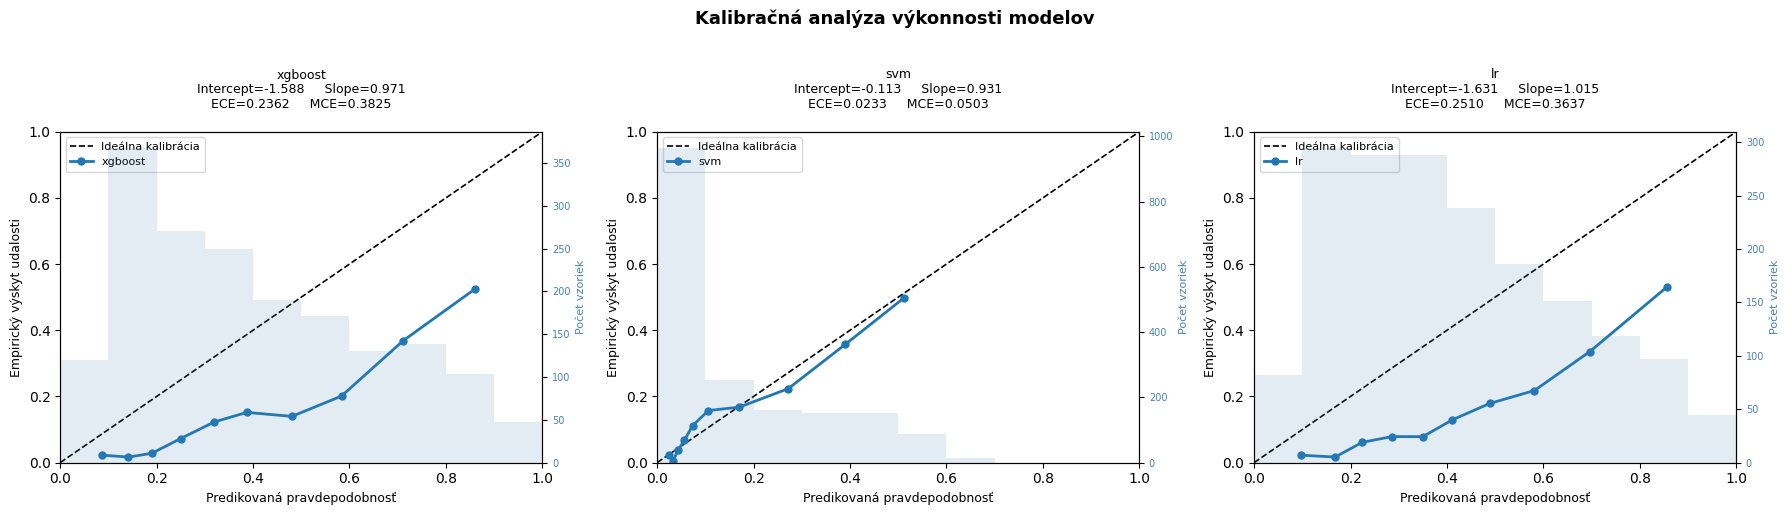

In [12]:
n_models = len(models_probabilities)
fig = plt.figure(figsize=(6 * n_models, 5))
gs  = gridspec.GridSpec(1, n_models, figure=fig)
fig.suptitle("Kalibračná analýza výkonnosti modelov", fontsize=13, fontweight="bold", y=1.02)

results = []
for i, (name, y_prob) in enumerate(models_probabilities.items()):
    ax = fig.add_subplot(gs[0, i])
    res = evaluate_calibration(name, y_true, y_prob, ax=ax, strategy="quantile")
    results.append(res)

plt.tight_layout()
plt.show()

In [13]:
summary = pd.DataFrame([{
    "model":        r["model"],
    "Intercept":    round(r["intercept"], 4),
    "p (int=0)":    round(r["p_intercept"], 4),
    "CI intercept": f"({r['ci_intercept'][0]:.3f}, {r['ci_intercept'][1]:.3f})",
    "Slope":        round(r["slope"], 4),
    "p (slope=1)":  round(r["p_slope"], 4),
    "CI slope":     f"({r['ci_slope'][0]:.3f}, {r['ci_slope'][1]:.3f})",
    "ECE":          round(r["ECE"], 4),
    "MCE":          round(r["MCE"], 4),
} for r in results]).set_index("model")

display(summary)

,Intercept,p (int=0),CI intercept,Slope,p (slope=1),CI slope,ECE,MCE
model,,,,,,,,
xgboost,-1.5885,0.0000,"(-1.733, -1.444)",0.9711,0.6448,"(0.848, 1.094)",0.2362,0.3825
svm,-0.1128,0.2768,"(-0.316, 0.091)",0.9306,0.2662,"(0.808, 1.053)",0.0233,0.0503
lr,-1.6310,0.0000,"(-1.776, -1.486)",1.0148,0.8244,"(0.884, 1.145)",0.2510,0.3637


**Model SVM** dosahuje najlepšiu kalibračnú kvalitu spomedzi hodnotených modelov.
- Intercept nadobúda hodnotu −0.1128, ktorá sa štatisticky významne nelíši od nuly (p = 0.277) a 95% interval spoľahlivosti (−0.316, 0.091) obsahuje hodnotu 0.
- Slope 0.9306 je blízky ideálnej hodnote 1 a štatisticky sa od nej nelíši (p = 0.266, CI: 0.808–1.532).

Tieto výsledky naznačujú absenciu výrazného systematického posunu aj skreslenia predikcií. Kalibračný graf potvrdzuje dobrú zhodu krivky s ideálnou priamkou naprieč rozsahom pravdepodobností. ECE = 0.0233 a MCE = 0.0503 ukazujú nízku priemernú aj maximálnu lokálnu odchýlku. Predikcie SVM modelu sú dobre kalibrované a predikované pravdepodobnosti zodpovedajú skutočnému výskytu udalosti.

Pri použití modelu SVM s výstupom pravdepodobností už však interne dochádza k aplikácii Platt scalingu. To znamená, že model je už implicitne kalibrovaný počas trénovania, čo vysvetľuje jeho dobré kalibračné vlastnosti bez potreby dodatočnej post-hoc kalibrácie.

**Model XGBoost** nie je správne kalibroavný. 
- Intercept −1.5885 sa štatisticky významne líši od nuly (p < 0.001, CI: −1.733 až −1.444), čo znamená systematické nadhodnotenie predikovaného rizika – model priradí pacientom vyššie pravdepodobnosti, než zodpovedajú skutočnému výskytu MCI. 
- Slope  0.9711 je veľmi blízky ideálnej hodnote 1 a štatisticky sa od nej nelíši (p = 0.6448, CI: 0.848–1.109), čo znamená, že predikcie nie sú výrazne deformované (roztiahnuté či stlačené), ale sú najmä posunuté.

Kalibračný graf ukazuje, že krivka modelu leží výrazne pod ideálnou priamkou. ECE = 0.2362 poukazuje na vysokú priemernú odchýlku a MCE = 0.3825 na výraznú lokálnu chybu. Kalibrácia modelu je nedostatočná a vyžaduje post-hoc korekciu.

**Model Logistická regresia** taktiež nie je správne kalibrovaný
- Intercept −1.631 sa štatisticky líši od 0 (p < 0.001, CI: −1.776 až −1.486), čo indikuje rovnako výrazné systematické nadhodnotenie rizika ako XGBoost. 
- Slope 1.0148 je blízky ideálnej hodnote 1 a štatisticky sa od nej nelíši (p = 0.8244, CI: 0.884–1.146) – predikcie sú iba posunuté nahor. 

Kalibračný graf ukazuje, že krivka modelu leží systematicky pod ideálnou priamkou. ECE = 0.2510 a MCE = 0.3637 poukazujú na výraznú kalibračnú chybu a sú porovnateľné s hodnotami XGBoost. Model potrebuje post-hoc kalibračnú korekciu.

In [14]:
for r in results:
    print(f"\n{'='*55}")
    print(f"  Detailné bin štatistiky: {r['model']}")
    print(f"{'='*55}")
    display(r["bin_df"].round(4).reset_index(drop=True))


  Detailné bin štatistiky: xgboost


,bin_lower,bin_upper,pocet_pacientov,mean_prediction,realita_ochorenia,rozdiel
0,0.0362,0.1172,179,0.0861,0.0223,0.0637
1,0.1172,0.1635,179,0.1415,0.0168,0.1247
2,0.1635,0.2152,179,0.1898,0.0279,0.1619
3,0.2152,0.2863,179,0.2499,0.0726,0.1772
4,0.2863,0.3507,178,0.3197,0.1236,0.1961
5,0.3507,0.4280,179,0.3868,0.1508,0.2360
6,0.4280,0.5265,179,0.4807,0.1397,0.3411
7,0.5265,0.6428,179,0.5836,0.2011,0.3825
8,0.6428,0.7738,179,0.7117,0.3687,0.3430
9,0.7738,0.9849,179,0.8609,0.5251,0.3357



  Detailné bin štatistiky: svm


,bin_lower,bin_upper,pocet_pacientov,mean_prediction,realita_ochorenia,rozdiel
0,0.0174,0.0292,179,0.0248,0.0223,0.0025
1,0.0292,0.0377,179,0.0330,0.0056,0.0274
2,0.0377,0.0498,179,0.0438,0.0391,0.0047
3,0.0498,0.0618,179,0.0563,0.0670,0.0108
4,0.0618,0.0864,178,0.0733,0.1124,0.0390
5,0.0864,0.1312,179,0.1061,0.1564,0.0503
6,0.1312,0.2175,179,0.1703,0.1676,0.0027
7,0.2175,0.3350,179,0.2719,0.2235,0.0484
8,0.3350,0.4421,179,0.3903,0.3575,0.0328
9,0.4421,0.6606,179,0.5115,0.4972,0.0143



  Detailné bin štatistiky: lr


,bin_lower,bin_upper,pocet_pacientov,mean_prediction,realita_ochorenia,rozdiel
0,0.0096,0.1399,179,0.0968,0.0223,0.0745
1,0.1399,0.1948,179,0.1679,0.0168,0.1512
2,0.1948,0.2560,178,0.2239,0.0562,0.1678
3,0.2560,0.3179,180,0.2856,0.0833,0.2023
4,0.3179,0.3764,178,0.3497,0.0787,0.2710
5,0.3764,0.4502,179,0.4110,0.1285,0.2825
6,0.4502,0.5353,179,0.4889,0.1788,0.3101
7,0.5353,0.6369,179,0.5816,0.2179,0.3637
8,0.6369,0.7637,179,0.6961,0.3352,0.3609
9,0.7637,0.9885,179,0.8564,0.5307,0.3257


#### Kalibračná analýza s uniformne rozdelenými intervalmi predikcií

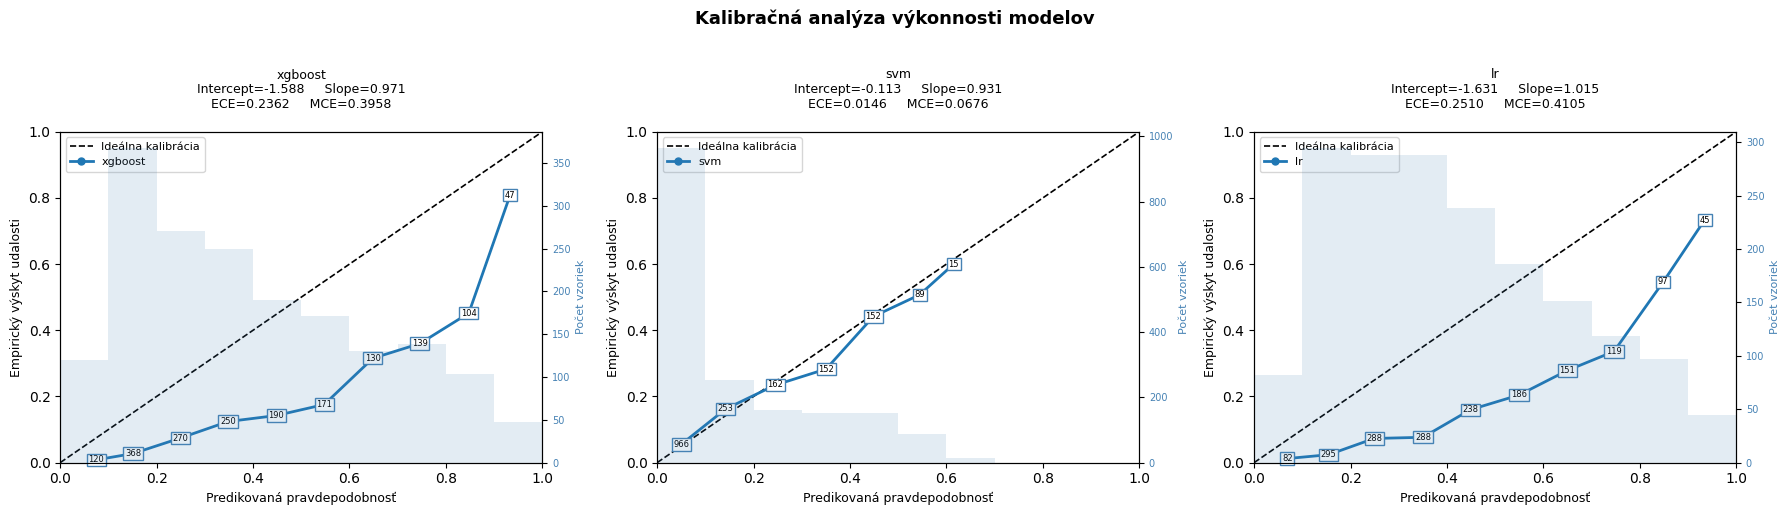

In [20]:
n_models = len(models_probabilities)
fig = plt.figure(figsize=(6 * n_models, 5))
gs  = gridspec.GridSpec(1, n_models, figure=fig)
fig.suptitle("Kalibračná analýza výkonnosti modelov", fontsize=13, fontweight="bold", y=1.02)

results = []
for i, (name, y_prob) in enumerate(models_probabilities.items()):
    ax = fig.add_subplot(gs[0, i])
    res = evaluate_calibration(name, y_true, y_prob, ax=ax, strategy="uniform")
    results.append(res)

plt.tight_layout()
plt.show()

In [19]:
summary = pd.DataFrame([{
    "model":        r["model"],
    "Intercept":    round(r["intercept"], 4),
    "p (int=0)":    round(r["p_intercept"], 4),
    "CI intercept": f"({r['ci_intercept'][0]:.3f}, {r['ci_intercept'][1]:.3f})",
    "Slope":        round(r["slope"], 4),
    "p (slope=1)":  round(r["p_slope"], 4),
    "CI slope":     f"({r['ci_slope'][0]:.3f}, {r['ci_slope'][1]:.3f})",
    "ECE":          round(r["ECE"], 4),
    "MCE":          round(r["MCE"], 4),
} for r in results]).set_index("model")

display(summary)

,Intercept,p (int=0),CI intercept,Slope,p (slope=1),CI slope,ECE,MCE
model,,,,,,,,
xgboost,-1.5885,0.0000,"(-1.733, -1.444)",0.9711,0.6448,"(0.848, 1.094)",0.2362,0.3958
svm,-0.1128,0.2768,"(-0.316, 0.091)",0.9306,0.2662,"(0.808, 1.053)",0.0146,0.0676
lr,-1.6310,0.0000,"(-1.776, -1.486)",1.0148,0.8244,"(0.884, 1.145)",0.2510,0.4105


In [17]:
for r in results:
    print(f"\n{'='*55}")
    print(f"  Detailné bin štatistiky: {r['model']}")
    print(f"{'='*55}")
    display(r["bin_df"].round(4).reset_index(drop=True))


  Detailné bin štatistiky: xgboost


,bin_lower,bin_upper,pocet_pacientov,mean_prediction,realita_ochorenia,rozdiel
0,0.0,0.1,120,0.0750,0.0083,0.0667
1,0.1,0.2,368,0.1508,0.0272,0.1237
2,0.2,0.3,270,0.2491,0.0741,0.1751
3,0.3,0.4,250,0.3481,0.1240,0.2241
4,0.4,0.5,190,0.4478,0.1421,0.3057
5,0.5,0.6,171,0.5476,0.1754,0.3721
6,0.6,0.7,130,0.6487,0.3154,0.3333
7,0.7,0.8,139,0.7461,0.3597,0.3864
8,0.8,0.9,104,0.8477,0.4519,0.3958
9,0.9,1.0,47,0.9334,0.8085,0.1249



  Detailné bin štatistiky: svm


,bin_lower,bin_upper,pocet_pacientov,mean_prediction,realita_ochorenia,rozdiel
0,0.0,0.1,966,0.0497,0.0549,0.0052
1,0.1,0.2,253,0.1419,0.1621,0.0201
2,0.2,0.3,162,0.2454,0.2346,0.0108
3,0.3,0.4,152,0.3505,0.2829,0.0676
4,0.4,0.5,152,0.4419,0.4276,0.0143
5,0.5,0.6,89,0.5344,0.5169,0.0176
6,0.6,0.7,15,0.6150,0.6000,0.0150



  Detailné bin štatistiky: lr


,bin_lower,bin_upper,pocet_pacientov,mean_prediction,realita_ochorenia,rozdiel
0,0.0,0.1,82,0.0689,0.0122,0.0567
1,0.1,0.2,295,0.1542,0.0237,0.1305
2,0.2,0.3,288,0.2491,0.0729,0.1761
3,0.3,0.4,288,0.3501,0.0764,0.2737
4,0.4,0.5,238,0.4485,0.1597,0.2889
5,0.5,0.6,186,0.5497,0.2043,0.3454
6,0.6,0.7,151,0.6493,0.2781,0.3711
7,0.7,0.8,119,0.7466,0.3361,0.4105
8,0.8,0.9,97,0.8488,0.5464,0.3025
9,0.9,1.0,45,0.9346,0.7333,0.2013
